# Part 2: Cross-Domain Acne Classification
## ACNE04 Patches → DermNet Transfer

**Pipeline**:
1. Extract positive/negative patches from ACNE04 GT bounding boxes
2. Train binary classifier (acne / not-acne) on patches
3. Apply domain adaptation for DermNet transfer
4. Evaluate on DermNet test set with Grad-CAM visualizations

### Table of Contents
1. [Configuration](#1-configuration)
2. [Imports](#2-imports)
3. [Patch Extraction](#3-patch-extraction)
4. [Dataset Stats & Visualization](#4-dataset-stats--visualization)
5. [Classification Model](#5-classification-model)
6. [Domain Adaptation](#6-domain-adaptation)
7. [DermNet Evaluation](#7-dermnet-evaluation)
8. [Grad-CAM Visualization](#8-grad-cam-visualization)
9. [Conclusions](#9-conclusions)

## 1. Configuration

In [1]:
import os, shutil

# ── Smoke test flag ───────────────────────────────────────────────────
# Set SMOKE = True for a fast end-to-end sanity check:
#   • patch extraction limited to 20 images per split
#   • 2 training epochs
#   • histogram reference from 20 patches
#   • DermNet eval on 2 batches only
SMOKE = False

# ── Paths (update to match your Google Drive layout) ─────────────────
DATA_COCO      = "/content/drive/MyDrive/Colab Notebooks/acne04/acne04-coco"
DERMNET_DIR    = "/content/drive/MyDrive/Colab Notebooks/dermnet"   # Kaggle download
PATCHES_DIR    = "/content/patches"   # where extracted patches are saved
OUT_DIR        = "/content/outputs_part2"

# ── Patch extraction ─────────────────────────────────────────────────
PATCH_SIZE     = 224     # resize all patches to NxN after cropping
PADDING        = 0.1    # fractional padding added around each bbox (10%)
NEG_PER_IMAGE  = 8      # negative patches to sample per image
NEG_MIN_SIZE   = 32     # minimum side length for a valid negative crop
SEED           = 67

# ── Training ─────────────────────────────────────────────────────────
EPOCHS         = 2 if SMOKE else 50
BATCH_SIZE     = 256 # for A100
LR             = 1e-4  # reference only — param groups set LRs directly
THRESHOLD      = 0.2   # decision threshold; tuned down from 0.5 to improve acne recall

# Wipe and recreate patch dirs so stale patches from prior runs don't linger.
# (Negatives are named by index; if the skin filter yields fewer than before,
# the old surplus files would silently remain without this reset.)
if os.path.exists(PATCHES_DIR):
    shutil.rmtree(PATCHES_DIR)

for d in [PATCHES_DIR, OUT_DIR,
          os.path.join(PATCHES_DIR, "train", "positive"),
          os.path.join(PATCHES_DIR, "train", "negative"),
          os.path.join(PATCHES_DIR, "val",   "positive"),
          os.path.join(PATCHES_DIR, "val",   "negative")]:
    os.makedirs(d, exist_ok=True)

import random, numpy as np, torch
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  SMOKE={SMOKE}")

Device: cuda  |  SMOKE=False


## 2. Imports

In [2]:
import json, shutil
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

print("Imports OK")

Imports OK


## 3. Google Drive & DermNet Download

Mount Drive, then download DermNet via `kagglehub` (handles auth automatically — will prompt for browser login on first use).

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import kagglehub

path = kagglehub.dataset_download("shubhamgoel27/dermnet")
print("Path to dataset files:", path)

# Override DERMNET_DIR to wherever kagglehub cached the download
DERMNET_DIR = path

# Verify structure
import os
for split in ("train", "test"):
    split_dir = os.path.join(DERMNET_DIR, split)
    if os.path.exists(split_dir):
        n_classes = len(os.listdir(split_dir))
        print(f"  {split}: {n_classes} class folders")

100%|██████████| 1.72G/1.72G [00:10<00:00, 181MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1
  train: 23 class folders
  test: 23 class folders


In [5]:
%%bash
pip install -q albumentations grad-cam scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.5 MB/s eta 0:00:00


## 3. Patch Extraction

Uses the **ground-truth COCO bounding boxes** from ACNE04.

In [6]:
import random
import cv2
from PIL import Image
from pathlib import Path
import json

# Wipe patch dirs every time this cell runs — guarantees no stale patches
# survive a partial re-run where cell-config was skipped.
for _split in ("train", "val"):
    for _cls in ("positive", "negative"):
        _d = Path(PATCHES_DIR) / _split / _cls
        if _d.exists():
            shutil.rmtree(_d)
        _d.mkdir(parents=True)


def iou_1d(a_min, a_max, b_min, b_max):
    """1-D overlap ratio — used to check negative patches don't overlap any bbox."""
    inter = max(0, min(a_max, b_max) - max(a_min, b_min))
    union = max(a_max, b_max) - min(a_min, b_min)
    return inter / union if union > 0 else 0.0


def overlaps_any_box(rx, ry, rw, rh, boxes, iou_thresh=0.1):
    """Return True if candidate region overlaps any GT box above threshold."""
    for bx, by, bw, bh in boxes:
        ox = iou_1d(rx, rx + rw, bx, bx + bw)
        oy = iou_1d(ry, ry + rh, by, by + bh)
        if ox > iou_thresh and oy > iou_thresh:
            return True
    return False


def is_skin_patch(patch_pil, min_skin_ratio=0.40):
    """Reject patches that are mostly non-skin (hair, teeth, eyes, background).

    Chai & Ngan (1999) skin locus in YCbCr, extended with a luminance bound:
      Y  in (40, 220)  -- dark hair passes Cr/Cb but has low Y; teeth have high Y
      Cr in (133, 177)
      Cb in (77, 127)
    A patch passes if >= min_skin_ratio of pixels satisfy all three constraints.
    """
    arr   = np.array(patch_pil)
    ycrcb = cv2.cvtColor(arr, cv2.COLOR_RGB2YCrCb)
    skin  = (
        (ycrcb[:, :, 0] > 40)  & (ycrcb[:, :, 0] < 220) &
        (ycrcb[:, :, 1] > 133) & (ycrcb[:, :, 1] < 177) &
        (ycrcb[:, :, 2] > 77)  & (ycrcb[:, :, 2] < 127)
    )
    return skin.mean() >= min_skin_ratio


def extract_patches(ann_path, img_dir, pos_dir, neg_dir,
                    patch_size=PATCH_SIZE, padding=PADDING,
                    neg_per_image=NEG_PER_IMAGE, neg_min_size=NEG_MIN_SIZE,
                    seed=SEED, max_images=None):
    random.seed(seed)
    with open(ann_path) as f:
        coco = json.load(f)

    # group annotations by image id
    img_to_anns = {}
    for ann in coco["annotations"]:
        img_to_anns.setdefault(ann["image_id"], []).append(ann)

    if max_images is not None:
        img_ids = list(img_to_anns.keys())[:max_images]
        img_to_anns = {k: img_to_anns[k] for k in img_ids}

    id_to_info = {img["id"]: img for img in coco["images"]}

    pos_count = neg_count = 0

    for img_id, anns in tqdm(img_to_anns.items(), desc=f"Extracting {Path(pos_dir).parent.name}"):
        info = id_to_info[img_id]
        img_path = Path(img_dir) / info["file_name"]
        if not img_path.exists():
            continue

        img = Image.open(img_path).convert("RGB")
        W, H = img.size
        boxes_xywh = [ann["bbox"] for ann in anns]   # [x, y, w, h] COCO format

        # ── Positive patches ────────────────────────────────────────
        for idx, (bx, by, bw, bh) in enumerate(boxes_xywh):
            pad_x = bw * padding
            pad_y = bh * padding
            x1 = max(0, bx - pad_x)
            y1 = max(0, by - pad_y)
            x2 = min(W, bx + bw + pad_x)
            y2 = min(H, by + bh + pad_y)

            if (x2 - x1) < 8 or (y2 - y1) < 8:   # skip degenerate boxes
                continue

            patch = img.crop((x1, y1, x2, y2)).resize((patch_size, patch_size))
            patch.save(Path(pos_dir) / f"{img_id}_{idx}.jpg")
            pos_count += 1

        # ── Negative patches ────────────────────────────────────────
        # Attempts raised to 100 to absorb extra rejections from skin filter.
        neg_size = max(neg_min_size, int(min(W, H) * 0.1))   # ~10% of image
        attempts = 0
        saved_neg = 0
        while saved_neg < neg_per_image and attempts < 100:
            attempts += 1
            rx = random.randint(0, max(0, W - neg_size))
            ry = random.randint(0, max(0, H - neg_size))
            if overlaps_any_box(rx, ry, neg_size, neg_size, boxes_xywh):
                continue
            patch = img.crop((rx, ry, rx + neg_size, ry + neg_size)).resize((patch_size, patch_size))
            if not is_skin_patch(patch):
                continue
            patch.save(Path(neg_dir) / f"{img_id}_neg{saved_neg}.jpg")
            saved_neg += 1
            neg_count += 1

    print(f"  Positives: {pos_count}  |  Negatives: {neg_count}")
    return pos_count, neg_count


_max_imgs = 20 if SMOKE else None

# Extract from train split
extract_patches(
    ann_path   = Path(DATA_COCO) / "train" / "_annotations.coco.json",
    img_dir    = Path(DATA_COCO) / "train",
    pos_dir    = Path(PATCHES_DIR) / "train" / "positive",
    neg_dir    = Path(PATCHES_DIR) / "train" / "negative",
    max_images = _max_imgs,
)

# Extract from val split
extract_patches(
    ann_path   = Path(DATA_COCO) / "valid" / "_annotations.coco.json",
    img_dir    = Path(DATA_COCO) / "valid",
    pos_dir    = Path(PATCHES_DIR) / "val" / "positive",
    neg_dir    = Path(PATCHES_DIR) / "val" / "negative",
    max_images = _max_imgs,
)

Extracting train: 100%|██████████| 118/118 [00:45<00:00,  2.60it/s]


  Positives: 1850  |  Negatives: 936


Extracting val: 100%|██████████| 25/25 [00:11<00:00,  2.24it/s]

  Positives: 307  |  Negatives: 200


(307, 200)

## 4. Dataset Stats & Visualization

In [ ]:
for split in ("train", "val"):
    pos = len(list((Path(PATCHES_DIR) / split / "positive").glob("*.jpg")))
    neg = len(list((Path(PATCHES_DIR) / split / "negative").glob("*.jpg")))
    print(f"{split:5s}  positive={pos:5d}  negative={neg:5d}  total={pos+neg:5d}")

train  positive= 1850  negative=  936  total= 2786
val    positive=  307  negative=  200  total=  507


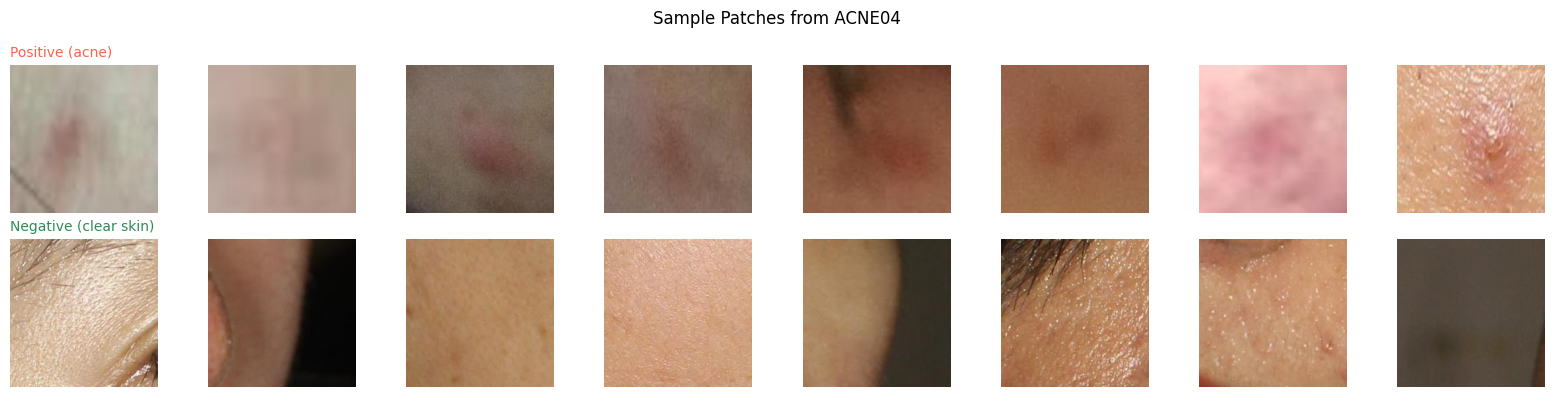

In [8]:
# Show sample positive and negative patches side by side
pos_files = list((Path(PATCHES_DIR) / "train" / "positive").glob("*.jpg"))[:8]
neg_files = list((Path(PATCHES_DIR) / "train" / "negative").glob("*.jpg"))[:8]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for ax, f in zip(axes[0], pos_files):
    ax.imshow(Image.open(f)); ax.axis("off")
axes[0][0].set_title("Positive (acne)", loc="left", fontsize=10, color="tomato")

for ax, f in zip(axes[1], neg_files):
    ax.imshow(Image.open(f)); ax.axis("off")
axes[1][0].set_title("Negative (clear skin)", loc="left", fontsize=10, color="seagreen")

plt.suptitle("Sample Patches from ACNE04", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sample_patches.png"), dpi=150)
plt.show()

## 5. Classification Model

ResNet-18 fine-tuned from ImageNet weights. `conv1`/`layer1`/`layer2` frozen; `layer3`/`layer4`/`fc` trained with differential learning rates. Single-logit binary head with BCEWithLogitsLoss.

In [9]:
import timm

IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(os.path.join(PATCHES_DIR, "train"), transform=train_tf)
val_ds   = ImageFolder(os.path.join(PATCHES_DIR, "val"),   transform=val_tf)

print("Class mapping:", train_ds.class_to_idx)  # {'negative': 0, 'positive': 1}

n_neg      = sum(1 for t in train_ds.targets if t == 0)
n_pos      = sum(1 for t in train_ds.targets if t == 1)
pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE)
print(f"Train: {n_pos} positive  {n_neg} negative  pos_weight={pos_weight.item():.2f}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

# ── Model ─────────────────────────────────────────────────────────────
model    = timm.create_model('resnet18', pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model    = model.to(DEVICE)

# Freeze conv1, bn1, layer1, layer2
for name, param in model.named_parameters():
    if any(name.startswith(p) for p in ('conv1', 'bn1', 'layer1', 'layer2')):
        param.requires_grad = False

# Differential LR: layer3 (1e-5) < layer4 (1e-4) < fc head (1e-3)
param_groups = [
    {'params': [p for n, p in model.named_parameters() if n.startswith('layer3') and p.requires_grad], 'lr': 1e-5},
    {'params': [p for n, p in model.named_parameters() if n.startswith('layer4') and p.requires_grad], 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3},
]

optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}  ({100 * trainable / total:.1f}%)")

Class mapping: {'negative': 0, 'positive': 1}
Train: 1850 positive  936 negative  pos_weight=0.51


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Trainable: 10,493,953 / 11,177,025  (93.9%)


Ep   1/50  loss=0.4602  val_F1=0.7543  best=0.7543 (ep 1)
Ep   5/50  loss=0.3014  val_F1=0.7902  best=0.7902 (ep 5)
Ep  10/50  loss=0.1622  val_F1=0.9099  best=0.9099 (ep 10)
Ep  15/50  loss=0.0997  val_F1=0.9306  best=0.9306 (ep 15)
Ep  20/50  loss=0.0682  val_F1=0.9346  best=0.9346 (ep 20)
Ep  25/50  loss=0.0521  val_F1=0.9329  best=0.9346 (ep 20)
Ep  30/50  loss=0.0437  val_F1=0.9329  best=0.9359 (ep 28)
Ep  35/50  loss=0.0320  val_F1=0.9342  best=0.9385 (ep 33)
Ep  40/50  loss=0.0283  val_F1=0.9387  best=0.9421 (ep 38)
Ep  45/50  loss=0.0265  val_F1=0.9370  best=0.9421 (ep 38)
Ep  50/50  loss=0.0232  val_F1=0.9361  best=0.9421 (ep 38)

Done. Best val F1=0.9421 at epoch 38. Checkpoint saved.


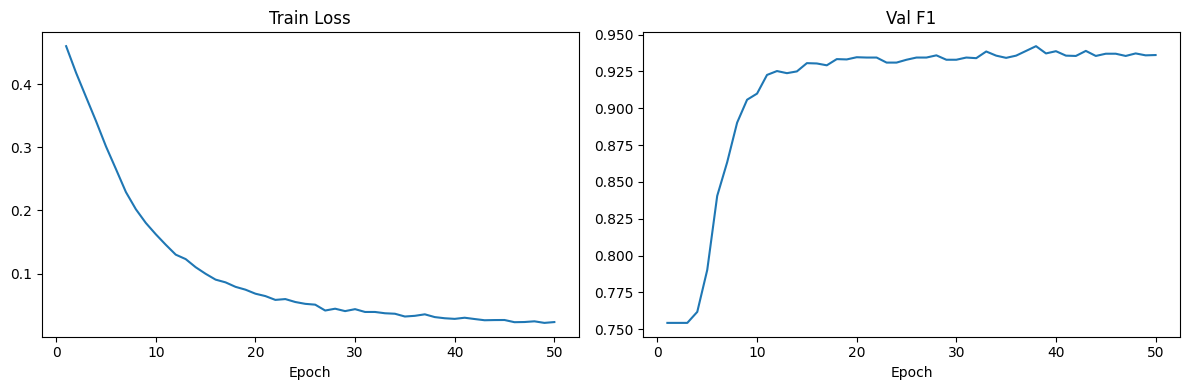

In [10]:
CKPT_PATH       = os.path.join(OUT_DIR, "best_resnet18.pth")
best_f1, best_epoch = 0.0, 0
history         = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)

    # ── Validate ───────────────────────────────────────────────────────
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            all_logits.append(model(imgs.to(DEVICE)).squeeze(1).cpu())
            all_labels.append(labels)

    logits_cat = torch.cat(all_logits)
    labels_cat = torch.cat(all_labels).numpy()
    preds      = (torch.sigmoid(logits_cat) > THRESHOLD).long().numpy()
    val_f1     = f1_score(labels_cat, preds)
    train_loss = running_loss / len(train_ds)

    scheduler.step(val_f1)

    if val_f1 > best_f1:
        best_f1, best_epoch = val_f1, epoch
        torch.save(model.state_dict(), CKPT_PATH)

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_f1': val_f1})

    if epoch % 5 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS}  loss={train_loss:.4f}  val_F1={val_f1:.4f}  best={best_f1:.4f} (ep {best_epoch})")

print(f"\nDone. Best val F1={best_f1:.4f} at epoch {best_epoch}. Checkpoint saved.")

hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df['epoch'], hist_df['train_loss']); axes[0].set(title='Train Loss', xlabel='Epoch')
axes[1].plot(hist_df['epoch'], hist_df['val_f1']);     axes[1].set(title='Val F1',     xlabel='Epoch')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 6. Domain Adaptation — Histogram Matching

Compute a per-channel histogram reference from ACNE04 training patches. At DermNet inference time each image is matched to this reference before the model sees it, closing the colour distribution gap without touching the training data.

Building histogram reference: 100%|██████████| 500/500 [00:00<00:00, 1815.85it/s]


Reference built from 500 patches | shape: (224, 224, 3)


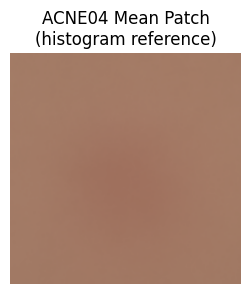

Domain adaptation transform ready.


In [11]:
import numpy as np
from skimage.exposure import match_histograms

# Build reference from up to 500 ACNE04 train patches (20 in smoke mode)
_ref_limit = 20 if SMOKE else 500

all_patch_files = (
    list(Path(PATCHES_DIR, "train", "positive").glob("*.jpg")) +
    list(Path(PATCHES_DIR, "train", "negative").glob("*.jpg"))
)
random.seed(SEED)
ref_sample    = random.sample(all_patch_files, min(_ref_limit, len(all_patch_files)))
ref_stack     = np.stack([
    np.array(Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    for p in tqdm(ref_sample, desc="Building histogram reference")
])
reference_img = ref_stack.mean(axis=0).astype(np.uint8)

np.save(os.path.join(OUT_DIR, "histogram_reference.npy"), reference_img)
print(f"Reference built from {len(ref_sample)} patches | shape: {reference_img.shape}")

plt.figure(figsize=(3, 3))
plt.imshow(reference_img)
plt.title("ACNE04 Mean Patch\n(histogram reference)")
plt.axis("off")
plt.savefig(os.path.join(OUT_DIR, "histogram_reference.png"), dpi=150)
plt.show()


class HistogramMatchTransform:
    """PIL Image → PIL Image: colour-matches image to ACNE04 reference."""
    def __init__(self, reference: np.ndarray):
        self.reference = reference

    def __call__(self, img: Image.Image) -> Image.Image:
        arr     = np.array(img.convert("RGB"))
        matched = match_histograms(arr, self.reference, channel_axis=-1)
        return Image.fromarray(matched.astype(np.uint8))


hist_match_tf = HistogramMatchTransform(reference_img)

# DermNet test transform: histogram match → resize → normalize
dermnet_tf = T.Compose([
    hist_match_tf,
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("Domain adaptation transform ready.")

## 7. DermNet Evaluation

Evaluate on the full DermNet test set. Class folders containing `"acne"` (case-insensitive) map to label 1; all others map to 0. Reports accuracy, F1, AUROC, and confusion matrix.

Acne class(es): ['Acne and Rosacea Photos']
DermNet test  acne=312  non-acne=3690
ROC optimal threshold: 0.280  (AUROC=0.5521)


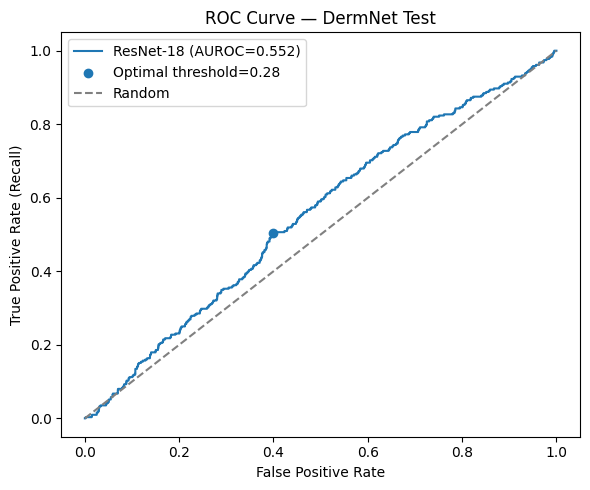

DermNet Test Results  (threshold=0.280)
  Accuracy : 0.5932
  F1-score : 0.1608
  AUROC    : 0.5521
              precision    recall  f1-score   support

    non-acne       0.93      0.60      0.73      3690
        acne       0.10      0.50      0.16       312

    accuracy                           0.59      4002
   macro avg       0.52      0.55      0.45      4002
weighted avg       0.87      0.59      0.69      4002



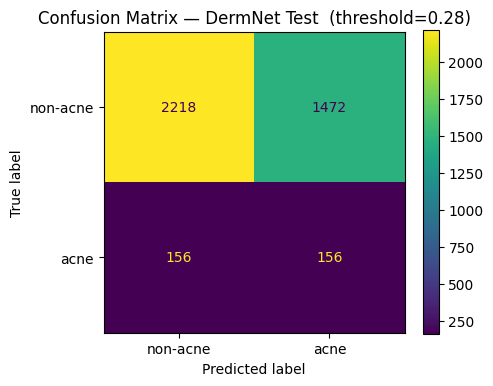

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_curve, precision_score, recall_score

dermnet_test_dir = os.path.join(DERMNET_DIR, "test")
dermnet_ds       = ImageFolder(dermnet_test_dir, transform=dermnet_tf)

acne_classes = [c for c in dermnet_ds.classes if "acne" in c.lower()]
assert acne_classes, f"No acne folder found in DermNet test. Available: {dermnet_ds.classes}"
print(f"Acne class(es): {acne_classes}")

acne_idxs      = {dermnet_ds.class_to_idx[c] for c in acne_classes}
binary_targets = [1 if t in acne_idxs else 0 for t in dermnet_ds.targets]
print(f"DermNet test  acne={sum(binary_targets)}  non-acne={len(binary_targets) - sum(binary_targets)}")

dermnet_loader = DataLoader(dermnet_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_probs = []
_smoke_batch_limit = 2 if SMOKE else None
with torch.no_grad():
    for i, (imgs, _) in enumerate(dermnet_loader):
        if _smoke_batch_limit is not None and i >= _smoke_batch_limit:
            break
        all_probs.append(torch.sigmoid(model(imgs.to(DEVICE)).squeeze(1)).cpu())

all_probs  = torch.cat(all_probs).numpy()
n_eval     = len(all_probs)
binary_arr = np.array(binary_targets[:n_eval])

if SMOKE:
    print(f"[SMOKE] Evaluated on {n_eval} samples (first {_smoke_batch_limit} batches only)")

# ── ROC curve + optimal threshold ─────────────────────────────────────
fpr, tpr, thresholds = roc_curve(binary_arr, all_probs)
auroc = roc_auc_score(binary_arr, all_probs)

# Youden's J statistic: maximise TPR - FPR (top-left corner of ROC)
optimal_idx       = int(np.argmax(tpr - fpr))
optimal_threshold = float(thresholds[optimal_idx])
print(f"ROC optimal threshold: {optimal_threshold:.3f}  (AUROC={auroc:.4f})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"ResNet-18 (AUROC={auroc:.3f})")
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], zorder=5,
           label=f"Optimal threshold={optimal_threshold:.2f}")
ax.plot([0, 1], [0, 1], "--", color="grey", label="Random")
ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate (Recall)",
       title="ROC Curve — DermNet Test")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "roc_curve.png"), dpi=150)
plt.show()

# Use ROC-optimal threshold for all downstream metrics
all_preds = (all_probs > optimal_threshold).astype(int)

acc = accuracy_score(binary_arr, all_preds)
f1  = f1_score(binary_arr, all_preds)
print(f"DermNet Test Results  (threshold={optimal_threshold:.3f})")
print(f"  Accuracy : {acc:.4f}")
print(f"  F1-score : {f1:.4f}")
print(f"  AUROC    : {auroc:.4f}")
print(f"{classification_report(binary_arr, all_preds, target_names=['non-acne', 'acne'])}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(binary_arr, all_preds, display_labels=['non-acne', 'acne'], ax=ax)
plt.title(f"Confusion Matrix — DermNet Test  (threshold={optimal_threshold:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

## 8. Grad-CAM Visualization

Visualize model attention on 10 DermNet test samples (5 acne + 5 non-acne) using Grad-CAM on `layer4`. Top row: histogram-matched input. Bottom row: activation overlay with prediction tick/cross.

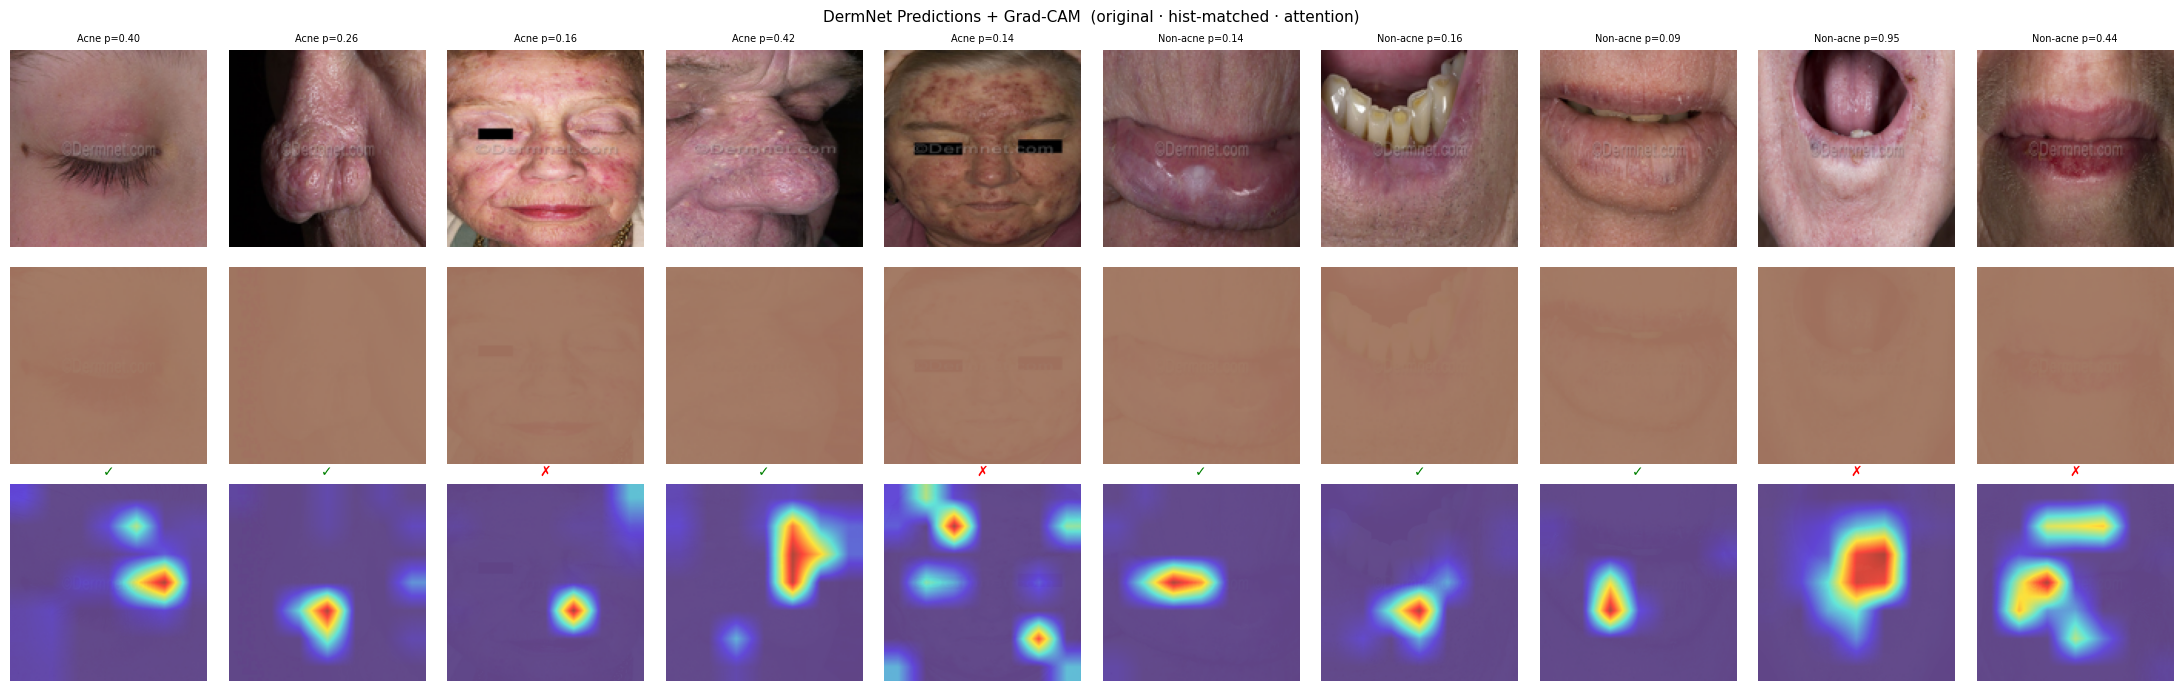

In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

# 5 acne + 5 non-acne samples
acne_sample    = [i for i, l in enumerate(binary_targets) if l == 1][:5]
nonacne_sample = [i for i, l in enumerate(binary_targets) if l == 0][:5]
sample_indices = acne_sample + nonacne_sample

# 3 rows: original input | histogram-matched input | Grad-CAM overlay
fig, axes = plt.subplots(3, 10, figsize=(22, 7))

for col, idx in enumerate(sample_indices):
    img_path   = dermnet_ds.imgs[idx][0]
    true_label = binary_targets[idx]

    pil_raw     = Image.open(img_path).convert("RGB")
    pil_matched = hist_match_tf(pil_raw)

    input_tensor = val_tf(pil_matched).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        prob = torch.sigmoid(model(input_tensor)).item()
    pred_label = int(prob > THRESHOLD)

    grayscale_cam = cam(input_tensor=input_tensor, targets=[BinaryClassifierOutputTarget(1)])[0]
    rgb_arr       = np.array(pil_matched.resize((IMG_SIZE, IMG_SIZE))).astype(np.float32) / 255.0
    cam_image     = show_cam_on_image(rgb_arr, grayscale_cam, use_rgb=True)

    # Row 0: original (unprocessed) image
    axes[0, col].imshow(pil_raw.resize((128, 128)))
    axes[0, col].set_title(f"{'Acne' if true_label else 'Non-acne'} p={prob:.2f}", fontsize=7)
    axes[0, col].axis("off")

    # Row 1: histogram-matched image (what the model actually sees)
    axes[1, col].imshow(pil_matched.resize((128, 128)))
    axes[1, col].axis("off")

    # Row 2: Grad-CAM overlay on matched image
    tick = "✓" if pred_label == true_label else "✗"
    axes[2, col].imshow(cam_image)
    axes[2, col].set_title(tick, fontsize=10, color="green" if pred_label == true_label else "red")
    axes[2, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("Hist-matched", fontsize=9)
axes[2, 0].set_ylabel("Grad-CAM", fontsize=9)
plt.suptitle("DermNet Predictions + Grad-CAM  (original · hist-matched · attention)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "gradcam_dermnet.png"), dpi=150)
plt.show()